In [1]:
# This installs the optimized kernels for the M1-era architecture adapted for cloud GPUs.
!pip install unsloth
!pip install --no-deps xformers trl peft accelerate bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/91

In [2]:
from unsloth import FastLanguageModel
import torch
import json
import pandas as pd
import re

# # 1. Load Model (Optimized for Kaggle T4)
# model_name = "unsloth/Llama-3.2-3B-Instruct"
# model, tokenizer = FastLanguageModel.from_pretrained(
#     model_name = model_name,
#     max_seq_length = 2048,
#     load_in_4bit = True,
# )
# # Fix the pad token warning
# tokenizer.pad_token = tokenizer.eos_token 
# FastLanguageModel.for_inference(model)

# 1. Load Qwen2.5-3B (Optimized for T4)
# Unsloth maintains optimized 4-bit versions of Qwen
# model_name = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit" 
model_name = "unsloth/Phi-3.5-mini-instruct-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = 2048,
    load_in_4bit = True, # Explicitly ensure 4-bit loading
)

# 2. Preparation for Inference
FastLanguageModel.for_inference(model)

# Note: Qwen typically handles its own padding/eos tokens correctly 
# in the Unsloth loader, but you can keep your safety fix:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-03-03 05:49:29.169795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772516969.364312      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772516969.420630      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772516969.870732      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772516969.870787      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772516969.870791      24 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.2.1: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.26G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/140 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [3]:
# --- Update in Step 3 (The Function) ---
def get_prediction(instruction):
    # messages = [
    #     {"role": "system", "content": "You are a smart home assistant. Classify instructions into one of these intents: light_on, light_off, ac_on, ac_off, vent_on, vent_off, fan_on, fan_off, heater_on, heater_off, multiplug_on, multiplug_off, tv_on, tv_off."},
    #     {"role": "user", "content": f"User says: \"{instruction}\"\n\nFormat your response exactly like this:\nReasoning: <one sentence logic>\nIntent: <label>"}
    # ]

    messages = [
        {
            "role": "system", 
            "content": (
                "You are an expert Home Automation Controller. Your task is to classify instructions."
                "into exactly one intent: light_on, light_off, ac_on, ac_off, vent_on, vent_off, "
                "fan_on, fan_off, heater_on, heater_off, multiplug_on, multiplug_off, tv_on, tv_off.\n\n"
                "Never provide more than one label."
            )
        },
        {
            "role": "user", 
            "content": (
                f"User says: \"{instruction}\"\n\n"
                "Format your response exactly like this:\n"
                "Reasoning: <one sentence logic>\n"
                "Intent: <single_label_only>"
            )
        }
    ]
    
    # tokenizer now creates the attention_mask automatically
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        return_tensors = "pt",
    ).to("cuda")

    outputs = model.generate(
        input_ids = inputs,
        # Add the attention mask here explicitly
        attention_mask = inputs.ne(tokenizer.pad_token_id).all(dim=0).unsqueeze(0) if hasattr(inputs, 'ne') else None,
        max_new_tokens = 64,
        temperature = 0.01,
        # Explicitly tell it which token to use for padding
        pad_token_id = tokenizer.eos_token_id
    )
    
    response = tokenizer.decode(outputs[0][len(inputs[0]):], skip_special_tokens=True)
    return response

In [4]:
# 3. Test on first 5 samples
input_file = "/kaggle/input/datasets/lochanbasyal/home-automation-intent-classification/augmented_automation_reasoning.jsonl"
print(f"{'='*20} STARTING 5-SAMPLE TEST {'='*20}\n")

with open(input_file, 'r') as f:
    for i, line in enumerate(f):
        if i >= 5: break # Stop after 5 samples
        
        data = json.loads(line)
        instruction = data['instruction']
        ground_truth = data['intent']
        
        print(f"SAMPLE #{i+1}")
        print(f"Instruction: {instruction}")
        print(f"Ground Truth: {ground_truth}")
        
        raw_output = get_prediction(instruction)
        
        print(f"Model Output:\n{raw_output}")
        print(f"{'-'*50}\n")

print(f"{'='*20} TEST COMPLETE {'='*20}")

==================== STARTING 5-SAMPLE TEST ====================

SAMPLE #1
Instruction: It's time to watch TV, can you turn on the TV?
Ground Truth: tv_on
Model Output:
Reasoning: The user wants to initiate an activity related to watching television.
Intent: tv_on
--------------------------------------------------

SAMPLE #2
Instruction: I want to lower the temperature, turn on the AC.
Ground Truth: ac_on
Model Output:
Reasoning: The user wants to reduce the temperature, which implies activating the air conditioning system.
Intent: ac_on
--------------------------------------------------

SAMPLE #3
Instruction: I want to feel warmer, turn on the heater.
Ground Truth: heater_on
Model Output:
Reasoning: The user's desire to feel warmer indicates a need for increased heat.
Intent: heater_on
--------------------------------------------------

SAMPLE #4
Instruction: It's too hot, turn off the heater.
Ground Truth: heater_off
Model Output:
Reasoning: The user wants to reduce the temperature

In [5]:
# 4. Test on all samples
print(f"{'='*20} STARTING ALL SAMPLE TEST {'='*20}\n")

with open(input_file, 'r') as f:
    for i, line in enumerate(f):
        # if i >= 5: break # Stop after 5 samples
        
        data = json.loads(line)
        instruction = data['instruction']
        ground_truth = data['intent']
        
        print(f"SAMPLE #{i+1}")
        print(f"Instruction: {instruction}")
        print(f"Ground Truth: {ground_truth}")
        
        raw_output = get_prediction(instruction)
        
        print(f"Model Output:\n{raw_output}")
        print(f"{'-'*50}\n")

print(f"{'='*20} TEST COMPLETE {'='*20}")

==================== STARTING ALL SAMPLE TEST ====================

SAMPLE #1
Instruction: It's time to watch TV, can you turn on the TV?
Ground Truth: tv_on
Model Output:
Reasoning: The user wants to initiate an activity related to watching television.
Intent: tv_on
--------------------------------------------------

SAMPLE #2
Instruction: I want to lower the temperature, turn on the AC.
Ground Truth: ac_on
Model Output:
Reasoning: The user wants to reduce the temperature, which implies activating the air conditioning system.
Intent: ac_on
--------------------------------------------------

SAMPLE #3
Instruction: I want to feel warmer, turn on the heater.
Ground Truth: heater_on
Model Output:
Reasoning: The user's desire to feel warmer indicates a need for increased heat.
Intent: heater_on
--------------------------------------------------

SAMPLE #4
Instruction: It's too hot, turn off the heater.
Ground Truth: heater_off
Model Output:
Reasoning: The user wants to reduce the temperatu

==================== STARTING FULL EVALUATION ====================

Processed 10 samples...
Processed 20 samples...
Processed 30 samples...
Processed 40 samples...
Processed 50 samples...
Processed 60 samples...
Processed 70 samples...
Processed 80 samples...
Processed 90 samples...
Processed 100 samples...
Processed 110 samples...
Processed 120 samples...
Processed 130 samples...
Processed 140 samples...
Processed 150 samples...
Processed 160 samples...
Processed 170 samples...
Processed 180 samples...
Processed 190 samples...
Processed 200 samples...
Processed 210 samples...
Processed 220 samples...
Processed 230 samples...
Processed 240 samples...
Processed 250 samples...
Processed 260 samples...
Processed 270 samples...
Processed 280 samples...
Processed 290 samples...
Processed 300 samples...
Processed 310 samples...
Processed 320 samples...
Processed 330 samples...
Processed 340 samples...
Processed 350 samples...
Processed 360 samples...
Processed 370 samples...
Processed 380 sa

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


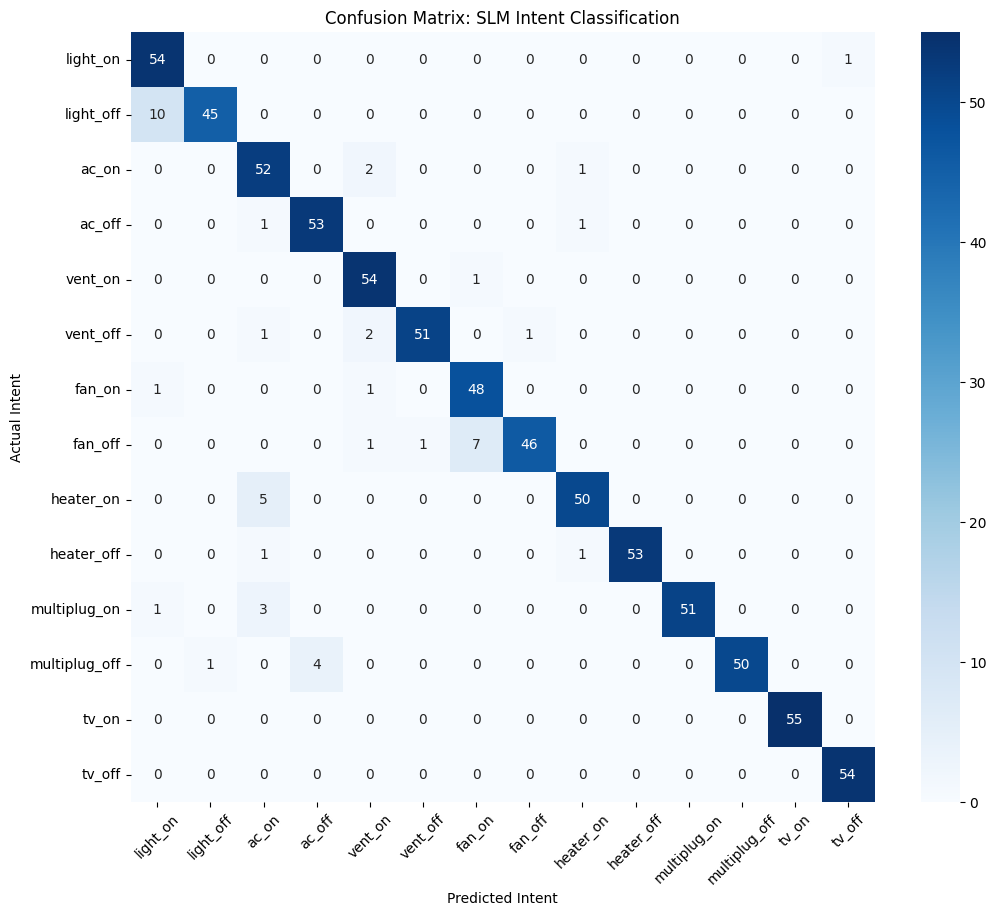

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# 1. Configuration
labels = [
    "light_on", "light_off", "ac_on", "ac_off", "vent_on", "vent_off", 
    "fan_on", "fan_off", "heater_on", "heater_off", "multiplug_on", 
    "multiplug_off", "tv_on", "tv_off"
]

results = []

print(f"{'='*20} STARTING FULL EVALUATION {'='*20}\n")

# 2. Run Inference
with open(input_file, 'r') as f:
    for i, line in enumerate(f):
        data = json.loads(line)
        instruction = data['instruction'] # Defined for use in get_prediction
        
        # Get the raw model response
        raw_output = get_prediction(instruction) # FIXED: Use local 'instruction'
        
        # --- PARSING LOGIC ---
        predicted_intent = "format_error"
        if "Intent:" in raw_output:
            # Extract label safely
            predicted_intent = raw_output.split("Intent:")[-1].strip().lower().split()[0].replace(".", "").replace(",", "")

        results.append({
            "instruction": instruction,
            "ground_truth_intent": data['intent'].strip().lower(),
            "ground_truth_reasoning": data.get('reasoning', 'N/A'),
            "predicted_intent": predicted_intent, # FIXED: Variable name
            "model_reasoning": raw_output.split("Intent:")[0].replace("Reasoning:", "").strip()
        })
        
        if (i+1) % 10 == 0:
            print(f"Processed {i+1} samples...")

# 3. Create DataFrame and Calculate Metrics
df_eval = pd.DataFrame(results)
y_true = df_eval['ground_truth_intent']
y_pred = df_eval['predicted_intent']

print(f"\n{'='*20} FINAL METRICS {'='*20}")
print(f"Overall Accuracy: {accuracy_score(y_true, y_pred) * 100:.2f}%")
print(f"Weighted F1-Score: {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"\nClassification Report:\n", classification_report(y_true, y_pred))

# 4. Print Misclassified Instructions (Your Request)
print(f"\n{'='*20} MISCLASSIFIED SAMPLES REPORT {'='*20}\n")
misclassified = df_eval[df_eval['ground_truth_intent'] != df_eval['predicted_intent']]

for idx, row in misclassified.iterrows():
    print(f"Instruction         : {row['instruction']}")
    print(f"Ground Truth Intent : {row['ground_truth_intent']}")
    print(f"Ground Truth Logic  : {row['ground_truth_reasoning']}")
    print(f"Model Predicted     : {row['predicted_intent']}")
    print(f"Model Reasoning     : {row['model_reasoning']}")
    print(f"{'-'*70}\n")

# 5. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: SLM Intent Classification')
plt.ylabel('Actual Intent')
plt.xlabel('Predicted Intent')
plt.xticks(rotation=45)
plt.show()

# Save results
df_eval.to_csv("final_evaluation_metrics.csv", index=False)